# Assignment - Segmentation without deep learning: watershed algorithm


**Computer Vision Course, University of Cologne, SoSe 2026**.   
In this assignment you will learn to segment images using the watershed algorithm. It represents a "clasiscal" computer vision algorithm and is currrently rarely used as the only approach to image segmentation. The principles of watershed are however reused in deep learning approaches.
In this assignement we will also learn to use thresholding and standard morphological operation on natural images.
We will use the watershed algorithm to perform instance segmentation first on natural images and then on histopathological images.

Some comments:
- Due on: 10/05/2026
- 25 points
- Upload this notebook completed with the different plots

In [1]:
#some imports

import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2hed
from skimage.exposure import rescale_intensity
from skimage import morphology
import cv2
from os import listdir
from os.path import isfile, join
import urllib.request

# Misc.
def url2img(url):
  req = urllib.request.urlopen(url)
  arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
  return cv2.imdecode(arr, -1)

## Part 1: Morphological operations (4 points)

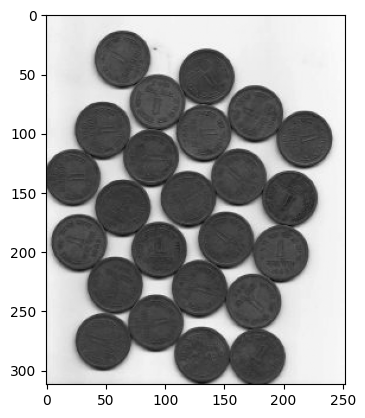

In [2]:
coins = cv2.cvtColor(url2img("https://raw.githubusercontent.com/bozeklab/ComputerVision_SS24/refs/heads/main/resources/assignment_3/water_coins.jpg"), cv2.COLOR_BGR2GRAY)
plt.imshow(coins, cmap="gray")

def show_image(image):
    plt.imshow(image,cmap="gray")

def show_images(images, titles=None, cmap="gray"):
    """
    Displays a list of images side-by-side.
    
    Args:
        images: List of np.ndarray images.
        titles: Optional list of strings for titles.
        cmap: Colormap (default is 'gray' for segmentation results).
    """
    cols = 3

    n = len(images)
    m = n // cols + 1
    # Create a figure with m rows and 'min(5,n)' columns
    fig, axes = plt.subplots(m, min(cols,n), figsize=(min(n,cols) * cols, m * cols))
    
    if n > 1:
        axes = axes.flatten()
    else: 
        axes = [axes]


    for i in range(n):
        axes[i].imshow(images[i], cmap=cmap)
        
        # Add title if provided and available for this index
        if titles and i < len(titles):
            axes[i].set_title(titles[i])
            
        axes[i].axis("off") # Clean look: no pixel coordinates

    plt.tight_layout()
    plt.show()


**Question 1 (1 point):** We want to segment the coins in the image, implement two thresholding methods (one using OpenCV and one without).

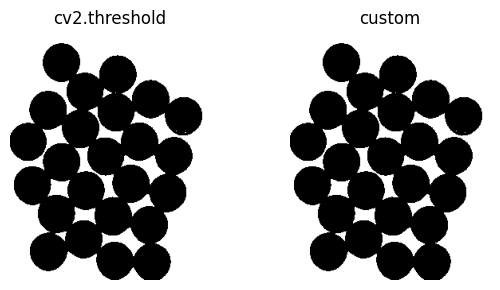

In [3]:
def simple_segment(input: np.ndarray, treshhold: float) -> np.ndarray:
    """Segmentation of coins."""
    output_height = input.shape[0]
    output_width = input.shape[1]
    output = np.zeros((output_height, output_width))

    max_val = np.max(input)
    #print(max_val)

    for y in range(output_height):
        for x in range(output_width):
            if input[y,x]/max_val > treshhold:
                output[y,x] = 1
            if input[y,x]/max_val < treshhold:
                output[y,x] = 0
            
    return output

ret, segemnted_two = cv2.threshold(coins,125,255,cv2.THRESH_BINARY)
segemnted_one = simple_segment(coins, 0.5)

#show_image(segemnted_two)
#show_image(segemnted_one)

show_images([segemnted_two, segemnted_one], ["cv2.threshold", "custom"])




**Question 2 (1 point):** Use the OpenCV function "erode" to separate the thresholded coins and "dilate" to increase their size (while keeping them separate).

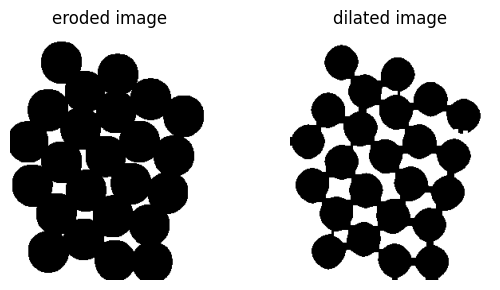

In [4]:
kernel = np.ones((5,5))

eroded_image = cv2.erode(segemnted_two,kernel)

dilated_image = cv2.dilate(segemnted_two,kernel)

show_images([eroded_image,dilated_image], ["eroded image", "dilated image"])

**Question 3 (1 point):** Now use the dilate and erode functions to remove the points in the background of the image "j_2.png".  
What is the name of the method you just used?  
Then use the OpenCV function `morphologyEx` to do the same, do you get the same results?

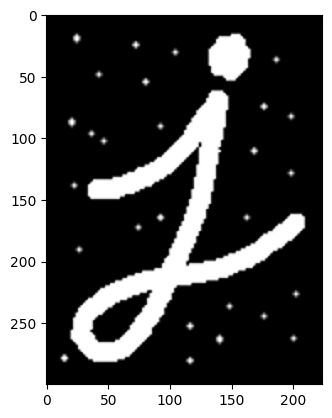

In [5]:
j_img_2 = cv2.cvtColor(url2img("https://raw.githubusercontent.com/bozeklab/ComputerVision_SS24/refs/heads/main/resources/assignment_3/j_2.png"), cv2.COLOR_BGR2GRAY)
plt.imshow(j_img_2, cmap="gray")

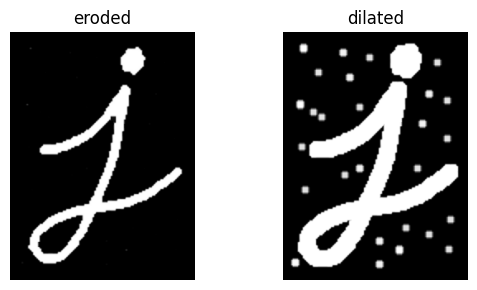

In [6]:
j_2_eroded = cv2.erode(j_img_2,kernel)

j_2_dilated = cv2.dilate(j_img_2,kernel)

show_images([j_2_eroded,j_2_dilated], ["eroded","dilated"])

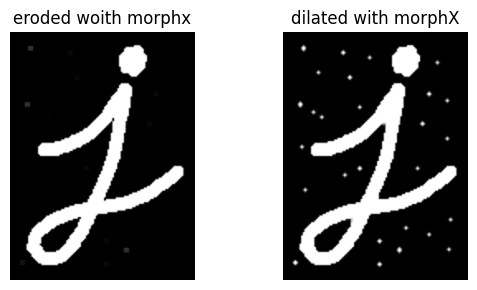

In [7]:
# As far as I understood the erosion and diletation are similar like a convolution but not linear

# maybe we call it non linear filtering?

j_2_morph_d = cv2.morphologyEx(j_img_2, cv2.MORPH_CLOSE, kernel)
j_2_morph_e = cv2.morphologyEx(j_img_2,cv2.MORPH_OPEN, kernel)


show_images([j_2_morph_e, j_2_morph_d], ["eroded woith morphx", "dilated with morphX"])

#I get similar but not the same result


**Question 4 (1 point):** Using the dilate and erode functions remove the points in the background of the image "j_3.png".  
What is the name of the method you just used?  
Then use the OpenCV function `morphologyEx` to do the same, do you get the same results?

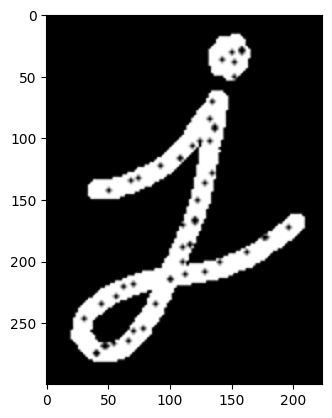

In [8]:
j_img_3 = cv2.cvtColor(url2img("https://raw.githubusercontent.com/bozeklab/ComputerVision_SS24/refs/heads/main/resources/assignment_3/j_3.png"), cv2.COLOR_BGR2GRAY)
plt.imshow(j_img_3, cmap="gray")

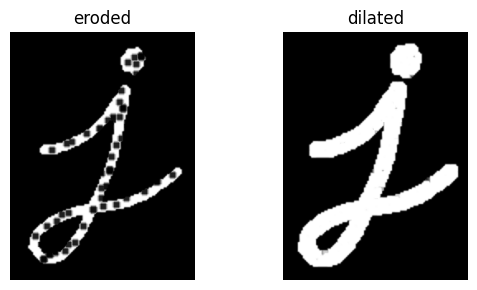

In [9]:

j_3_eroded = cv2.erode(j_img_3,kernel)

j_3_dilated = cv2.dilate(j_img_3,kernel)

show_images([j_3_eroded,j_3_dilated], ["eroded","dilated"])

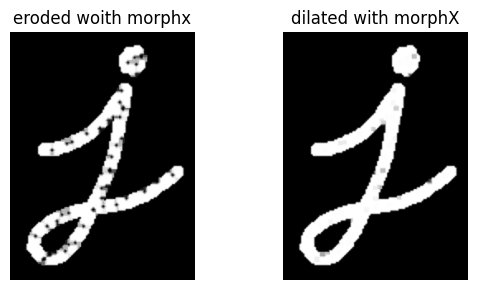

In [10]:
j_3_morph_d = cv2.morphologyEx(j_img_3, cv2.MORPH_CLOSE, kernel)
j_3_morph_e = cv2.morphologyEx(j_img_3,cv2.MORPH_OPEN, kernel)


show_images([j_3_morph_e, j_3_morph_d], ["eroded woith morphx", "dilated with morphX"])

#i get similar but not the same result

## Watershed tutorial (7 points)

Watershed algorithm was created to perform image segmentation. The input to the algorithm are maps in which each pixel is assigned a probability of belonging to foregound. The algorithm interprets as pixels values as a local topography (elevation points). It floods basins (foreground pixels in our case) until basins attributed to different markers meet on watershed lines. Or in other words: ‚Raindrops’ fall on each pixel and the gradient (direction of the highest descent) is used to decide where the rain is drained to. Each flooded area is labeled individually. The following figure visualizes the process and should help to understand the algorithm better.
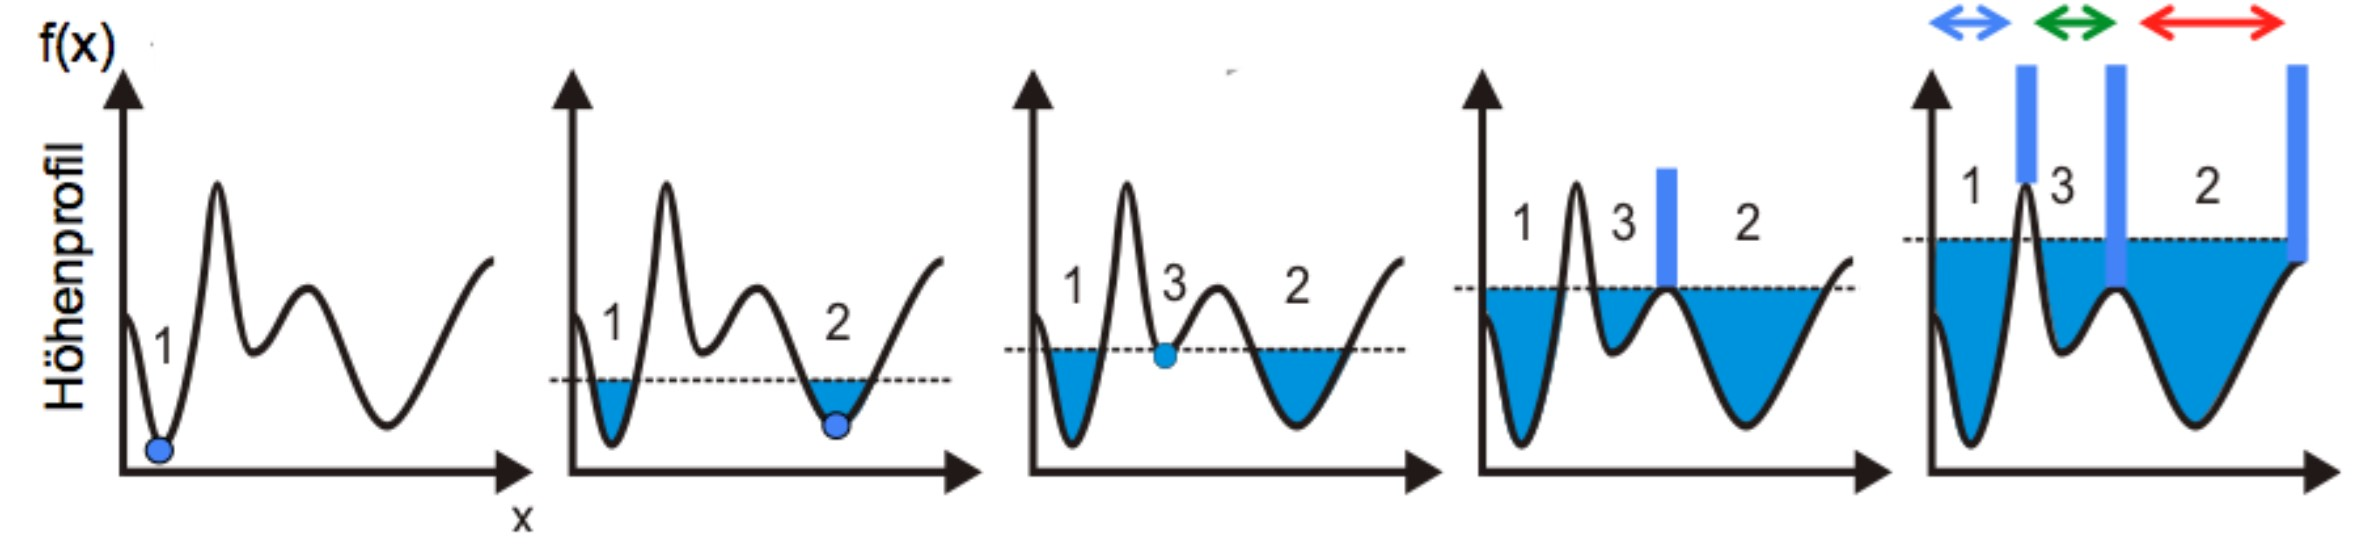


**Question 1 (7 points):** Look for a tutorial on watershed using OpenCV and use it to apply this method on the peaches images. The goal is to segment the foreground peaches as individual peach (instance segmentation).   
Plot each important step of the segmentation, the results as a segmentation mask (instance segmentation) and draw the contours of each peach on the original image.


* 4 points for coding the correct algorithm using OpenCV functions.
* 1 point for the plots.
* 1 point for commenting your code.   
* 1 point for the segmentation results (1 point for very good, 0.5 for good and 0 for bad).   

Hint : Don't hesitate to play with the different parameters to  obtain the best segmentation as possible

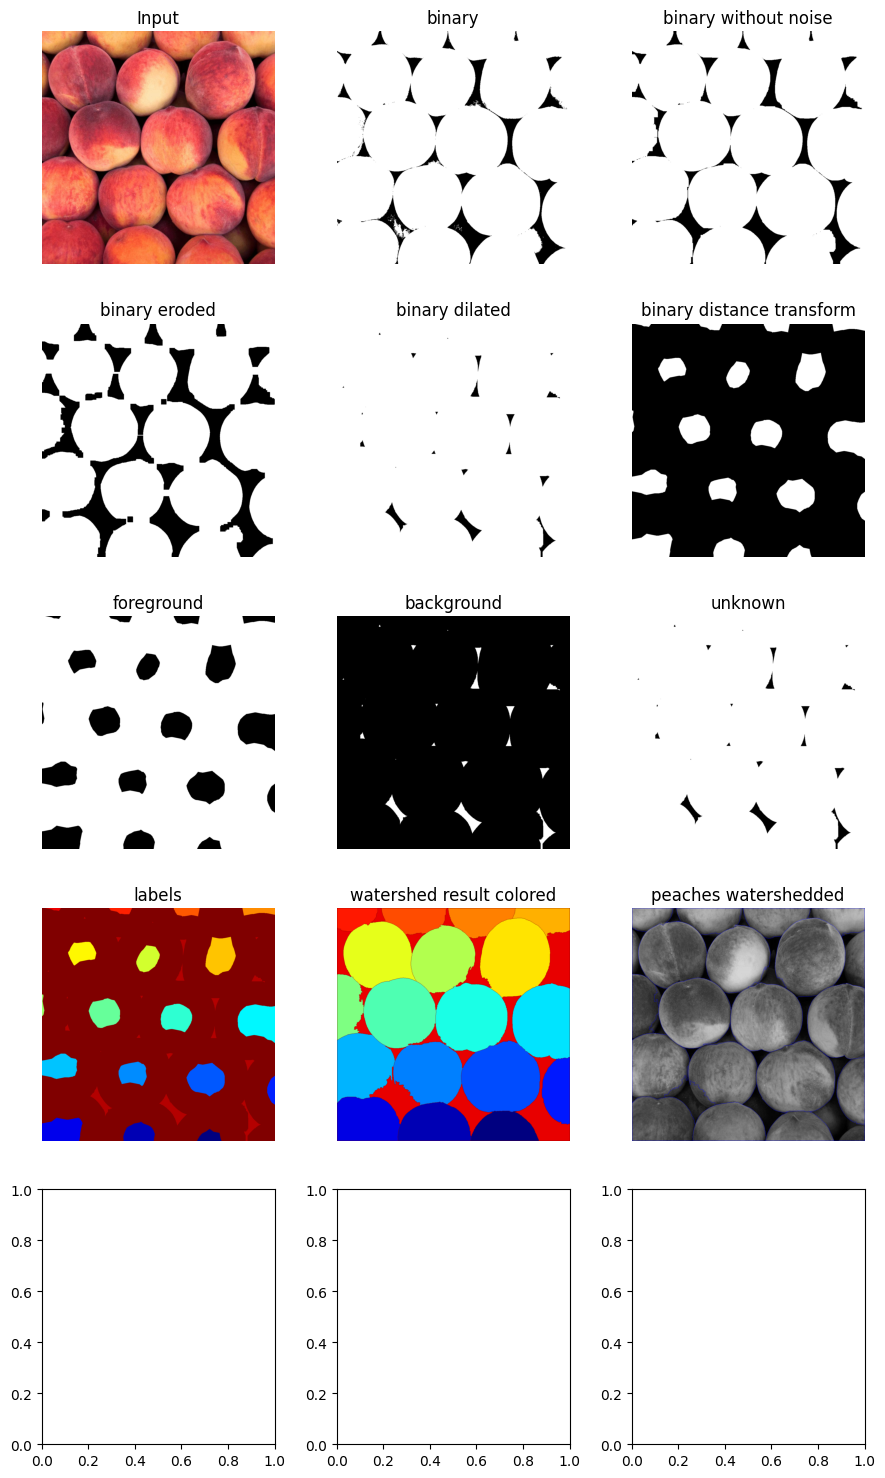

In [ ]:
peaches = cv2.cvtColor(url2img("https://raw.githubusercontent.com/bozeklab/ComputerVision_SS24/refs/heads/main/resources/assignment_3/peches.jpg"), cv2.COLOR_BGR2RGB)
#plt.imshow(peaches)

# A preparation for watershed (find start regions)

    # for each peach and each background area we need to define a group of pixels inside that area 
    # for the watershed to work it has to be one group each and the group has to be connected. 

    # we use dilate to find the background
    # to find the foreground we cant use erosion because the peaches are connected (still we do it do demonstrate)
    # we use distance transform another cv2 function to find the inner of the peaches. 

# 1 convert to greyscale 

peaches_gray = cv2.cvtColor(peaches,cv2.COLOR_BGR2GRAY)

# 2. Find B subset of Background and P subset of Peaches as big as possible using erosion, diletate

    # find binary
ret, peaches_bin_raw = cv2.threshold(peaches_gray,30,255,cv2.THRESH_BINARY)

    # remove white noise in background

peaches_bin = cv2.morphologyEx(peaches_bin_raw,cv2.MORPH_OPEN,kernel) 

    # erode

kernel = np.ones([25,25])

peaches_bin_eroded = cv2.erode(peaches_bin,kernel)
    # dilate
peaches_bin_dilated = cv2.dilate(peaches_bin,kernel)

# Finding inner of peaches using distance transform 
dist_transform = cv2.distanceTransform(peaches_bin,cv2.DIST_L2,5)
ret, peaches_bin_dist_trans = cv2.threshold(dist_transform,0.5*dist_transform.max(),255,0)

# 3. Define start regions for watershed

# we do this by defining binaries that are 1 for background, foreground and unknown. 

background = 255 - peaches_bin_dilated
foreground = np.int8(peaches_bin_dist_trans)
 
unknown = 255 - background - foreground
    # Notes: - Now what is black in peaches_bin_dilated is background
    #        - what is white in peaches_bin_eroded is foreground

# then we give different peaches different labels and make sure they dont equal background and unknown label

ret, labeled_peaches = cv2.connectedComponents(foreground)

labeled_peaches += 1 # so that background gets label 1

labeled_peaches[unknown == 255] = 0 # 0 is the label for unknown

# some normailizing and cv2 magic to make markers visible: 


def color_labels(labels):
    
    normalized_labels = cv2.normalize(
        labels, 
        None, 
        alpha=0, 
        beta=255, 
        norm_type=cv2.NORM_MINMAX, 
        dtype=cv2.CV_8U
    )

    colored_labels = cv2.applyColorMap(normalized_labels, cv2.COLORMAP_JET)

    return colored_labels

colored_labels = color_labels(labeled_peaches)





watershed_result = cv2.watershed(peaches,labeled_peaches)


watershed_result_color = color_labels(watershed_result)

# watershed puts -1 at border of peaches: 

peaches_watershedded = np.where(watershed_result[...,None] == -1, [0, 0, 255], cv2.cvtColor(peaches_gray, cv2.COLOR_GRAY2BGR)).astype(np.uint8)

# show images

def thicken_line(img, kernel, color = [0,0,255]):
    n,m, f = img.shape
    a,b = kernel.shape
    result = np.zeros([n,m,3])
    found = False

    for y in range(n-2*a):
        y = y + a
        for x in range(m-2*b):
            x = x + b
            found = False
            for p in range(2*a):
                if found:
                    break
                p - a
                for q in range(2*b): 
                    if found:
                        break
                    q - b
                    if np.array_equal(img[y+a,x+b],color):
                        result[y,x] = color
                        found = True


    return result


kernel = np.ones([5,5])
#peaches_watershedded = thicken_line(peaches_watershedded, kernel, [0,0,255])

show_images([peaches,
             peaches_bin_raw,
             peaches_bin,
             peaches_bin_eroded,
             peaches_bin_dilated,
             peaches_bin_dist_trans,
             foreground,
             background,
             unknown,
             colored_labels, 
             watershed_result_color,
             peaches_watershedded],
             ["Input",
              "binary",
              "binary without noise",
              "binary eroded",
              "binary dilated",
              "binary distance transform",
              "foreground",
              "background",
              "unknown",
              "labels",
              "watershed result colored",
              "peaches watershedded"
             ])






## Cellular segmentation (14 points)



Now that we know how to use the watershed algorithm on natural images, let's try it on histopathological images.
We will segment nuclei in histopathology images of size 128 x 128 pixels. These images represent a specific tumour called diffuse large B-cell lymphoma (DLBCL).
Download data_DLBCL.zip, unzip the content. If you are using colab, upload the directly the zip file and unzip it using the command below.

In [77]:
#!unzip -uq "data_DLBCL.zip" -d ""

In [78]:
# This is now path to images:
IM_PATH = "data/images"
# Here is how we list files in that folder:
files = [f for f in listdir(IM_PATH) if isfile(join(IM_PATH, f))]
files = sorted(files)
print("There are %i images in the folder %s" % (len(files), IM_PATH))

# path to ground truth masks:
M_PATH = "data/masks"
# Here is how we list files in that folder:
m_files = [f for f in listdir(M_PATH) if isfile(join(M_PATH, f))]
m_files = sorted(m_files)
print("There are %i masks in the folder %s" % (len(m_files), M_PATH))

There are 58 images in the folder data/images
There are 58 masks in the folder data/masks


**Question 1 (1 point):** Open and show the image of index one and its ground truth mask.

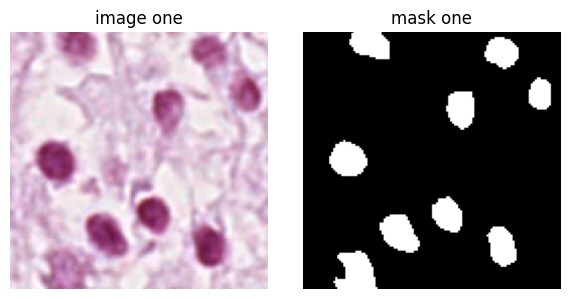

In [79]:
import os

image_dir = 'data/images'
mask_dir = 'data/masks'

image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))


# 4. Construct full file paths
image_path = os.path.join(image_dir, image_files[1])
mask_path = os.path.join(mask_dir, mask_files[1])


img_one = cv2.imread(image_path)
mask_one = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) 

show_images([img_one,mask_one],["image one", "mask one"])

We will first try to segment nuclei in this image and then run our algorithm on the rest of the images.   
The samples were stained with hematoxylin and eosin which highlights relevant structures (like cell nuclei) but the digitized images of these samples are saved in RGB format. Thus, we convert the RGB image to a color space named Haematoxylin-Eosin-DAB (HED) which produces a better representation of the actual staining.

**Question 2 (3 points):** Using a scikit-image function, convert the RGB image to the HED color space. Find which of the staining color is used the stain the nuclei of the cell and select the corresponding channel. We will use it for the segmentation.   
Help: Further segmentation algorithms require the image to be in unsigned integer with 8 bytes (uint8) type. As the HED image in in float values we need to cast them to uint8.

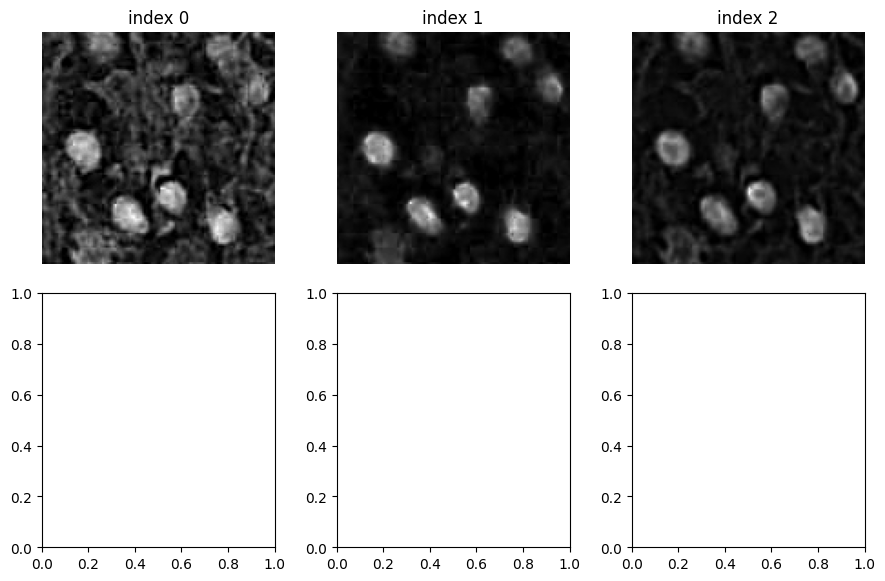

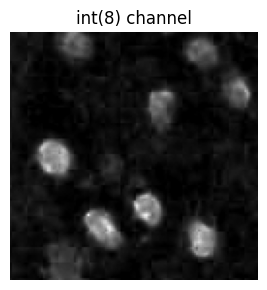

In [80]:

# 1. Convert the RGB image to the HED color space using scikit-image
hed_image = rgb2hed(img_one)

h_channel_0 = hed_image[:, :, 0]
h_channel_1 = hed_image[:, :, 1]
h_channel_2 = hed_image[:, :, 2]


show_images([h_channel_0,h_channel_1,h_channel_2], ["index 0", "index 1", "index 2"])

# -> index 1 i suppose
h_channel = h_channel_1

h_rescaled = rescale_intensity(h_channel, out_range=(0, 255))
nuclei_uint8 = h_rescaled.astype(np.uint8)

show_images([h_channel],["int(8) channel"])

**Question 3 (5 points):** Based on your previous watershed code for the natural images do the same for this histopathological image.
As before, plot each important step of the segmentation, the results as a segmentation mask (instance segmentation) and draw the contours of each nucleus on the original image.

* 2 points for coding the correct algorithm using OpenCV functions.
* 1 point for the plots.
* 1 point for commenting your code.   
* 1 point for the segmentation results (1 point for very good, 0.5 for good and 0 for bad).   

Hint : Don't hesitate to play with the different parameters to  obtain the best segmentation as possible

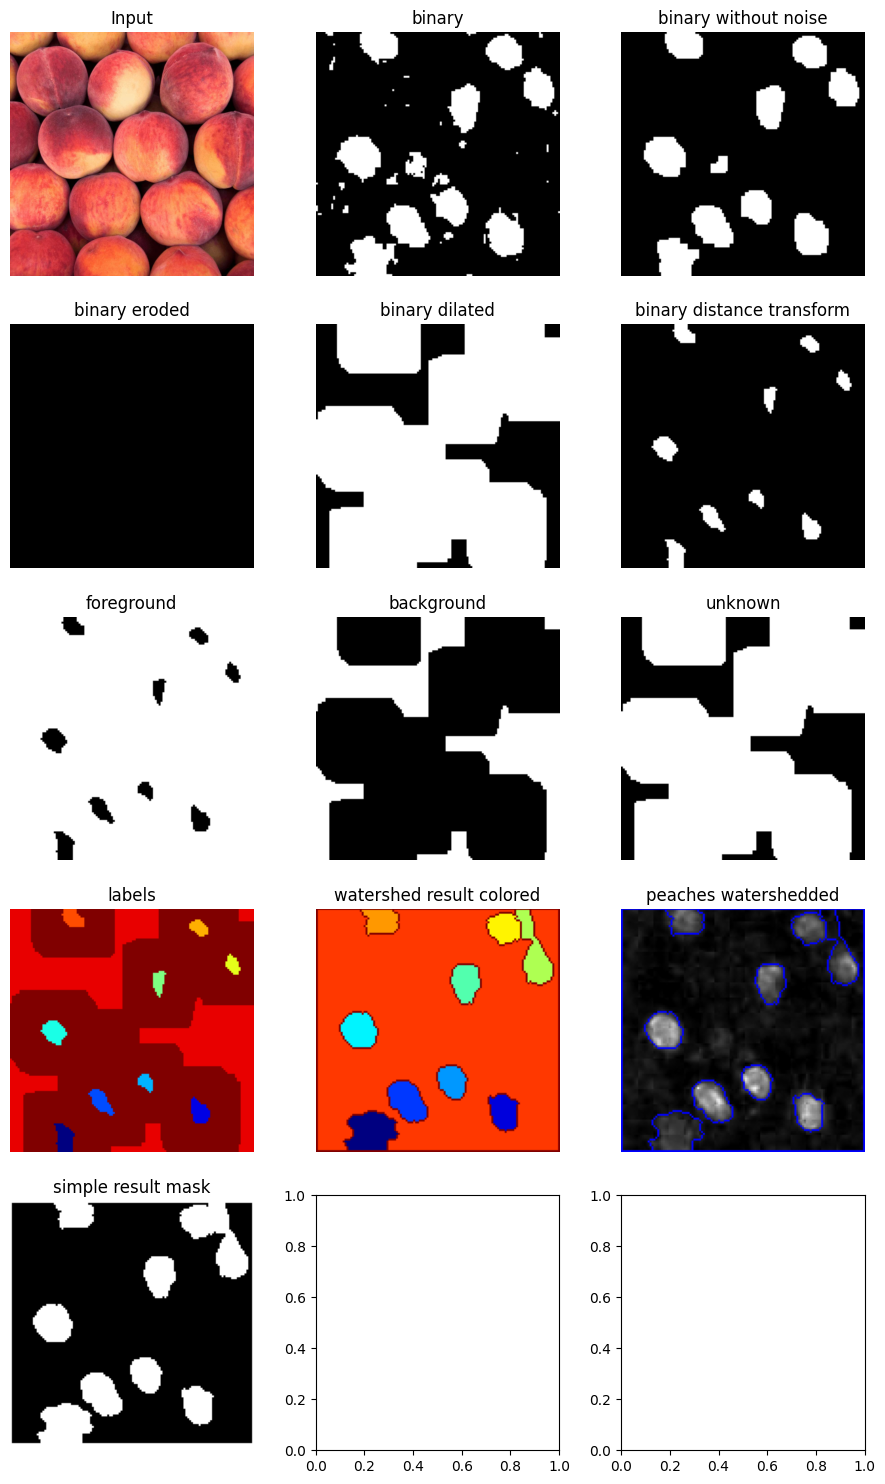

In [81]:

# Rename vars to resuse code
peqches = img_one

peaches_gray = h_channel
peaches_gray = h_rescaled.astype(np.uint8)

# 2. Find B subset of Background and P subset of Peaches as big as possible using erosion, diletate

    # find binary
ret, peaches_bin_raw = cv2.threshold(peaches_gray,30,255,cv2.THRESH_BINARY)

    # remove white noise in background

kernel = np.ones([5,5])

peaches_bin = cv2.morphologyEx(peaches_bin_raw,cv2.MORPH_OPEN,kernel) 

    # erode

kernel = np.ones([25,25])

peaches_bin_eroded = cv2.erode(peaches_bin,kernel)
    # dilate
peaches_bin_dilated = cv2.dilate(peaches_bin,kernel)

# Finding inner of peaches using distance transform 
dist_transform = cv2.distanceTransform(peaches_bin,cv2.DIST_L2,5)
ret, peaches_bin_dist_trans = cv2.threshold(dist_transform,0.5*dist_transform.max(),255,0)

# 3. Define start regions for watershed

# we do this by defining binaries that are 1 for background, foreground and unknown. 

background = 255 - peaches_bin_dilated
foreground = np.int8(peaches_bin_dist_trans)
 
unknown = 255 - background - foreground
    # Notes: - Now what is black in peaches_bin_dilated is background
    #        - what is white in peaches_bin_eroded is foreground

# then we give different peaches different labels and make sure they dont equal background and unknown label

ret, labeled_peaches = cv2.connectedComponents(foreground)

labeled_peaches += 1 # so that background gets label 1

labeled_peaches[unknown == 255] = 0 # 0 is the label for unknown

# some normailizing and cv2 magic to make markers visible: 


def color_labels(labels):
    
    normalized_labels = cv2.normalize(
        labels, 
        None, 
        alpha=0, 
        beta=255, 
        norm_type=cv2.NORM_MINMAX, 
        dtype=cv2.CV_8U
    )

    colored_labels = cv2.applyColorMap(normalized_labels, cv2.COLORMAP_JET)

    return colored_labels

colored_labels = color_labels(labeled_peaches)





watershed_result = cv2.watershed(img_one,labeled_peaches)


watershed_result_color = color_labels(watershed_result)

# watershed puts -1 at border of peaches: 

peaches_watershedded = np.where(watershed_result[...,None] == -1, [0, 0, 255], cv2.cvtColor(peaches_gray, cv2.COLOR_GRAY2BGR)).astype(np.uint8)


n,m = watershed_result.shape

simple_mask = np.ones([n,m])

simple_mask = np.where(watershed_result[...] == 1, 0, simple_mask)

# show images





show_images([peaches,
             peaches_bin_raw,
             peaches_bin,
             peaches_bin_eroded,
             peaches_bin_dilated,
             peaches_bin_dist_trans,
             foreground,
             background,
             unknown,
             colored_labels, 
             watershed_result_color,
             peaches_watershedded,
             simple_mask],
             ["Input",
              "binary",
              "binary without noise",
              "binary eroded",
              "binary dilated",
              "binary distance transform",
              "foreground",
              "background",
              "unknown",
              "labels",
              "watershed result colored",
              "peaches watershedded",
              "simple result mask"
             ])






**Question 4 (1 point):** To measure how good our automatic segmentation is, we are using the DICE score:
$$ DICE = \frac{2 * | Pred \cap GT |}{|Pred| + |GT|} $$ with Pred being the our segmentation and GT being the ground truth mask. If the model segments the nuclei perfectly, then $$ 2 * |Pred| \cap |GT|  = |Pred| + |GT|$$ and the dice score is 1. As a corner case, we define the dice score to be 1 if the prediction as well as the ground truth only consists of background.  
Implement a function to calculate the dice score between the ground truth and your automatic segmentation.

1.9690621288526313


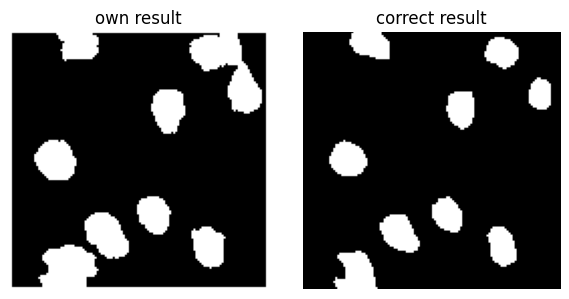

In [82]:
def dice(mask,control):
    Pred_and_GT = np.sum(mask * control)    
    Pred = np.sum(mask)
    Gt = np.sum(control)
    if (Pred == 0):
        if (Gt == 0): 
            dice = 1
            return dice
    dice = 2 * Pred_and_GT / (Pred + Gt)
    return dice

print(dice(simple_mask, mask_one))

show_images([simple_mask,mask_one], ["own result","correct result"])

**Question 5 (4 points, 1 point each):**
* Encapsulate everything you did in a function with parameters.
* In a loop, apply the segmentation algorithm to every image of the dataset and calculate the dice score of each image and the mean dice score.
* Plot the ground truth and the results for different image with very different Dice score (at least three).
* Comment on the result of the watershed algorithm for the segmentation of nuclei. Whould you recommend this method ? and why ? Argument.

** No i would not reccomend this method because it appears that it is very sensitive to like all the calibration values. Like for the bad examples with dice lowest and dice highest i could achieve better dice if i played with the intital values, but then for the good dice the results would be bad. how should the program now from the image how to set up its values correctly? **

In [83]:
def apply_watershed_segmentation(img_one, thresh_val=30, max_val=255, open_ksize=5, morph_ksize=25, dist_mask_size=5, dist_ratio=0.5, border_color=[0, 0, 255]):
    # Rename vars to resuse code
    img_copy = img_one

    hed_image = rgb2hed(img_one)

    h_channel = hed_image[:, :, 1]

    img_gray = h_channel
    img_gray = h_rescaled.astype(np.uint8)

    # 2. Find B subset of Background and P subset of Peaches as big as possible using erosion, diletate

        # find binary
    ret, bin_raw = cv2.threshold(img_gray,thresh_val,max_val,cv2.THRESH_BINARY)

        # remove white noise in background

    kernel = np.ones([open_ksize,open_ksize])

    bin_clean = cv2.morphologyEx(bin_raw,cv2.MORPH_OPEN,kernel) 

        # erode

    kernel = np.ones([morph_ksize,morph_ksize])

    bin_eroded = cv2.erode(bin_clean,kernel)
        # dilate
    bin_dilated = cv2.dilate(bin_clean,kernel)

    # Finding inner of peaches using distance transform 
    dist_transform = cv2.distanceTransform(bin_clean,cv2.DIST_L2,dist_mask_size)
    ret, bin_dist_trans = cv2.threshold(dist_transform,dist_ratio*dist_transform.max(),max_val,0)

    # 3. Define start regions for watershed

    # we do this by defining binaries that are 1 for background, foreground and unknown. 

    background = max_val - bin_dilated
    foreground = np.int8(bin_dist_trans)
     
    unknown = max_val - background - foreground
        # Notes: - Now what is black in peaches_bin_dilated is background
        #        - what is white in peaches_bin_eroded is foreground

    # then we give different peaches different labels and make sure they dont equal background and unknown label

    ret, labeled_objects = cv2.connectedComponents(foreground)

    labeled_objects += 1 # so that background gets label 1

    labeled_objects[unknown == max_val] = 0 # 0 is the label for unknown

    # some normailizing and cv2 magic to make markers visible: 


    def color_labels(labels):
        
        normalized_labels = cv2.normalize(
            labels, 
            None, 
            alpha=0, 
            beta=255, 
            norm_type=cv2.NORM_MINMAX, 
            dtype=cv2.CV_8U
        )

        colored_labels = cv2.applyColorMap(normalized_labels, cv2.COLORMAP_JET)

        return colored_labels

    colored_labels = color_labels(labeled_objects)





    watershed_result = cv2.watershed(img_one,labeled_objects)


    watershed_result_color = color_labels(watershed_result)

    # watershed puts -1 at border of peaches: 

    img_watershedded = np.where(watershed_result[...,None] == -1, border_color, cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)).astype(np.uint8)


    n,m = watershed_result.shape

    simple_mask = np.ones([n,m])

    simple_mask = np.where(watershed_result[...] == 1, 0, simple_mask)

    # show images


    return simple_mask

Mean Values of dice is:  0.7792543221586975


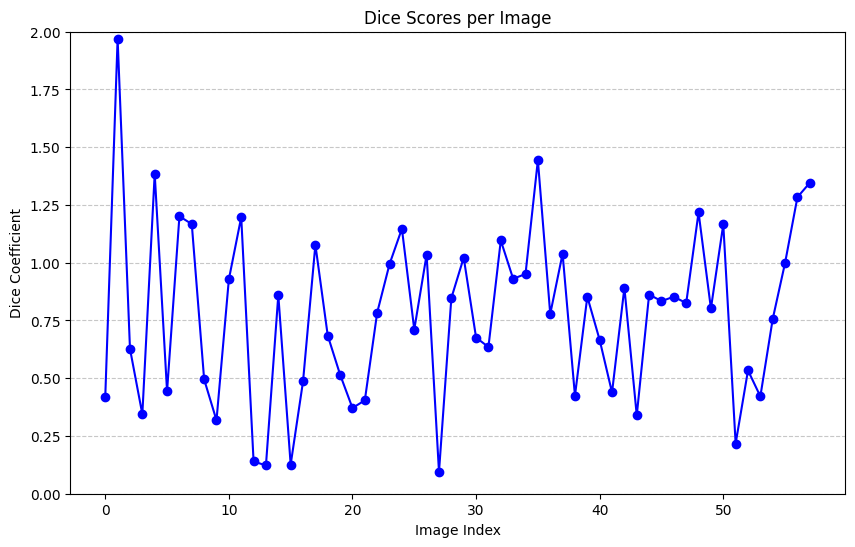

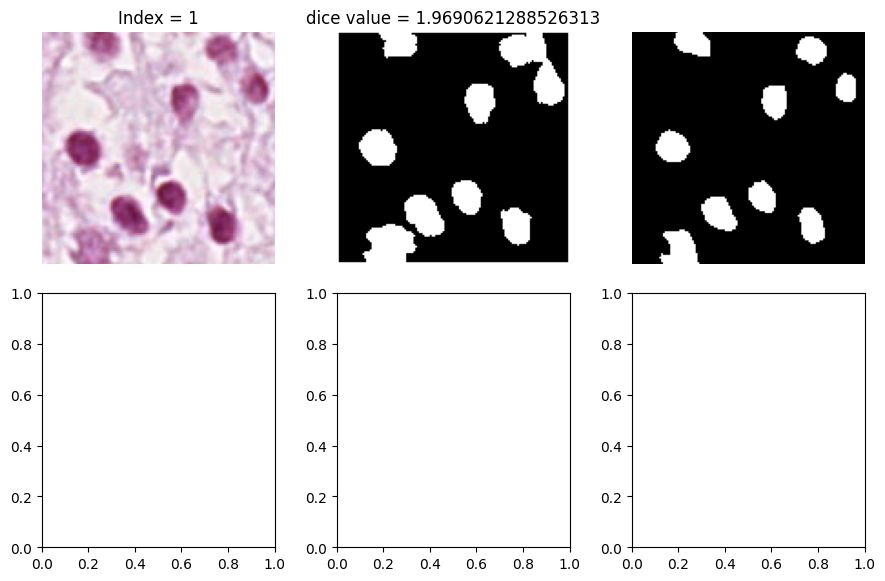

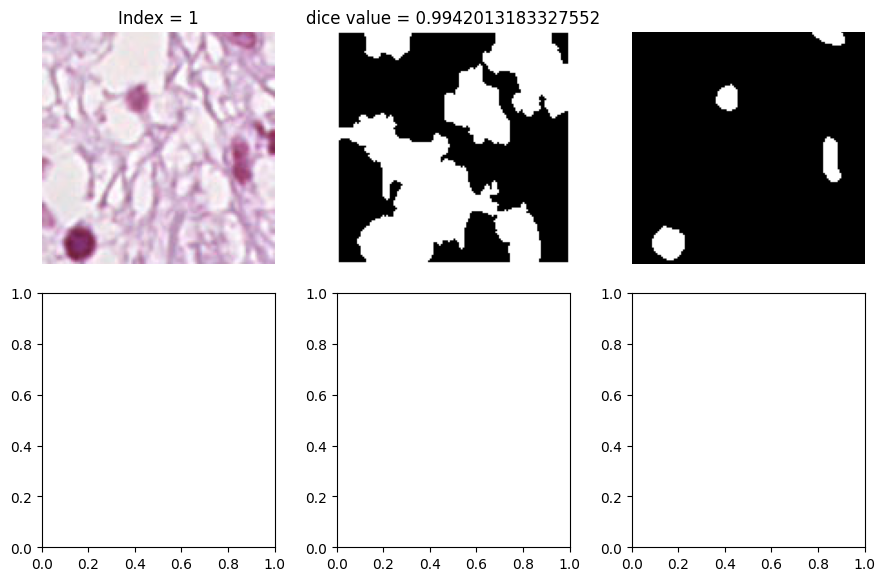

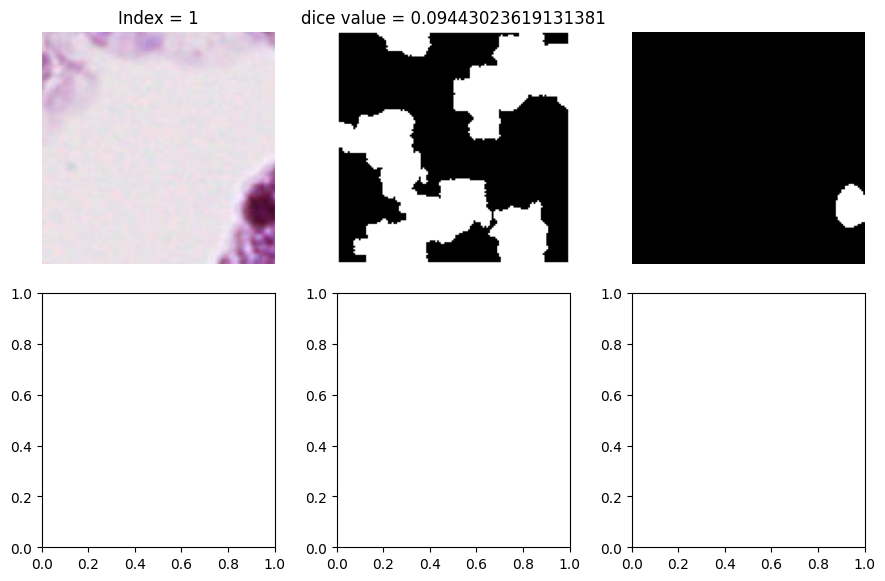

In [84]:
image_path = os.path.join(image_dir, image_files[1])
mask_path = os.path.join(mask_dir, mask_files[1])


img_one = cv2.imread(image_path)
mask_one = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) 

dice_values = []
masks_watershed = []
masks = []
images = []

for image_file, mask_file in zip(image_files,mask_files):

    image_path = os.path.join(image_dir, image_file)
    mask_path = os.path.join(mask_dir, mask_file)

    image = cv2.imread(image_path)
    mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

    masks.append( mask )
    images.append( image )

    masks_watershed.append( apply_watershed_segmentation(image) )

    dice_values.append( dice(masks_watershed[-1],mask) )

print("Mean Values of dice is: ", np.mean(dice_values))

plt.figure(figsize=(10, 6))
plt.plot(dice_values, marker='o', linestyle='-', color='b')
plt.title('Dice Scores per Image')
plt.xlabel('Image Index')
plt.ylabel('Dice Coefficient')
plt.ylim(0, 2) # Dice scores are typically between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

indexes = [1,23,27]

for i in indexes: 

    dice_val = dice(masks_watershed[i],masks[i])
    show_images([images[i],masks_watershed[i],masks[i]],["Index = 1", f"dice value = {dice_val}" ])

# Feedback
Please fill out this section to help us improve the course for next year.  
1. How long did it take you to do this assignment?
2. Was it too hard, too easy or just perfect?
3. If you have other (constructive) comments, don't hesitate to share.

1. It took me like 10 hours i would say. 

2. it was not to hard but it felt a little tidious.

3. i actually liked this assignment. it is just kind of hard to make it to all the lectures and exercise classes if i spend this much time on the assignments.